In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv(
    "../data/processed/olist_master.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date",
                 "order_estimated_delivery_date"],
)
print(df.shape)
df.head()

(94612, 18)


,order_id,customer_id,seller_id,product_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,product_weight_g,product_category_name_english,seller_state,customer_state,distance_km,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,500.0,housewares,SP,SP,18.576110,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,400.0,perfumery,SP,BA,851.495069,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,420.0,auto,SP,GO,514.410666,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,450.0,pet_shop,MG,RN,1822.226336,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,250.0,stationery,SP,SP,29.676625,-9.238171,0


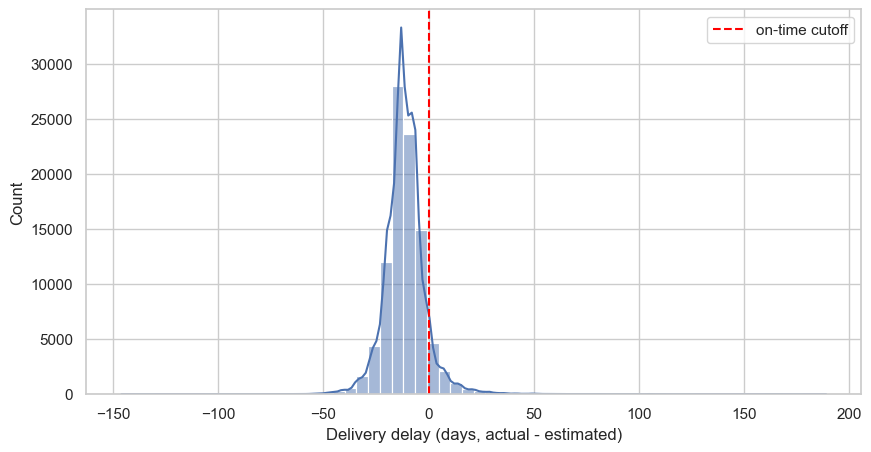

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["delivery_delay_days"], bins=60, kde=True, ax=ax)
ax.axvline(0, color="red", linestyle="--", label="on-time cutoff")
ax.set_xlabel("Delivery delay (days, actual - estimated)")
ax.legend()
plt.show()

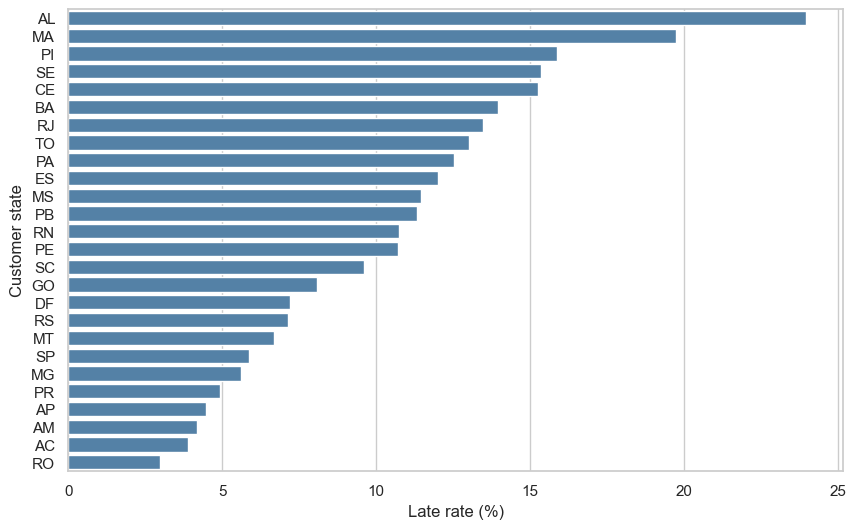

In [5]:
state_rate = (
    df.groupby("customer_state")["is_late"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=state_rate["mean"] * 100, y=state_rate.index, ax=ax, color="steelblue")
ax.set_xlabel("Late rate (%)")
ax.set_ylabel("Customer state")
plt.show()

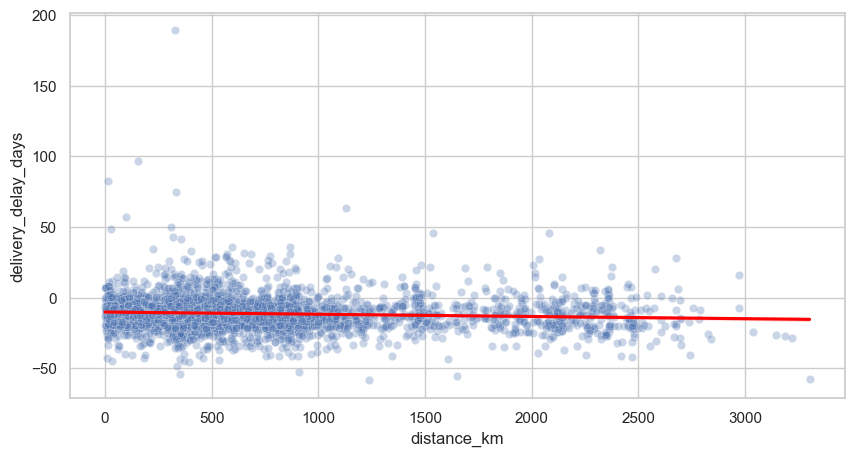

In [6]:
fig, ax = plt.subplots()
sample = df.sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="distance_km", y="delivery_delay_days", alpha=0.3, ax=ax)
sns.regplot(data=sample, x="distance_km", y="delivery_delay_days", scatter=False,
            color="red", ax=ax)
plt.show()

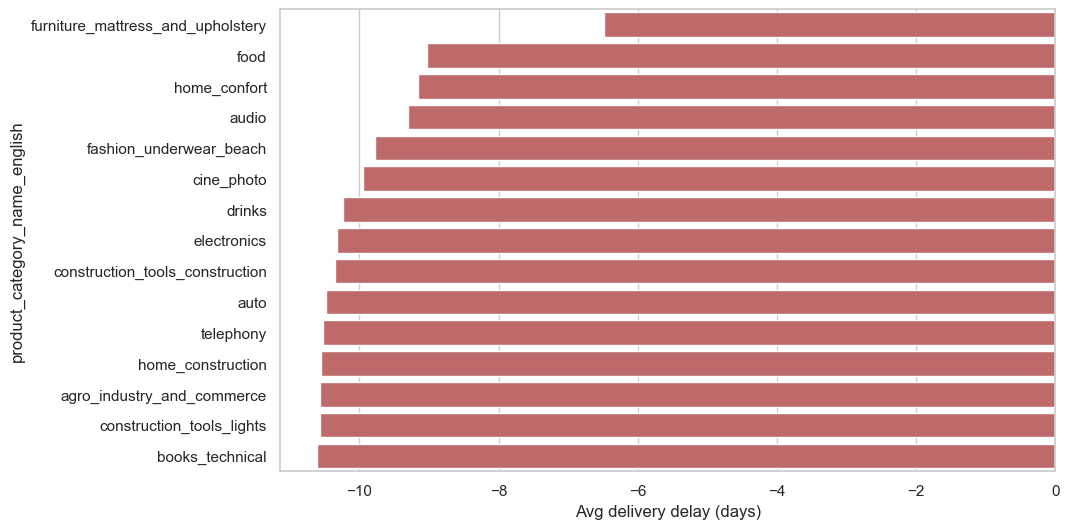

In [7]:
cat_delay = (
    df.groupby("product_category_name_english")["delivery_delay_days"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=cat_delay["mean"], y=cat_delay.index, ax=ax, color="indianred")
ax.set_xlabel("Avg delivery delay (days)")
plt.show()

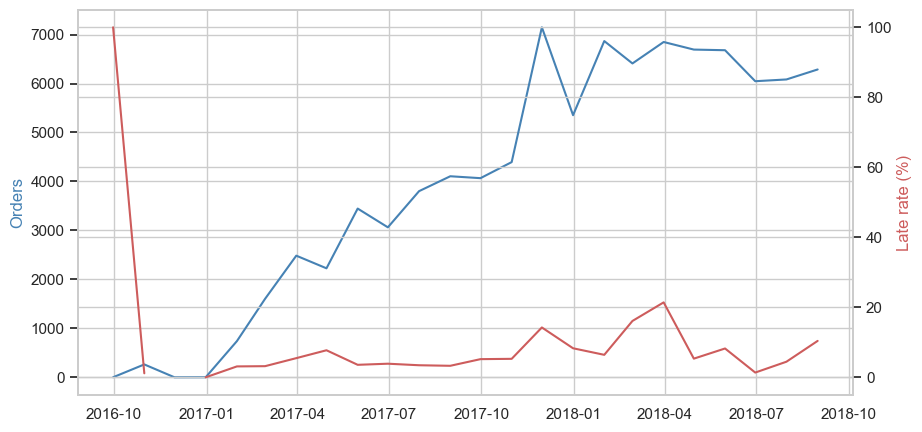

In [9]:
monthly = (
    df.set_index("order_purchase_timestamp")
    .resample("ME")
    .agg(total_orders=("order_id", "count"), late_rate=("is_late", "mean"))
)
fig, ax1 = plt.subplots()
ax1.plot(monthly.index, monthly["total_orders"], color="steelblue", label="Orders")
ax1.set_ylabel("Orders", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["late_rate"] * 100, color="indianred", label="Late rate %")
ax2.set_ylabel("Late rate (%)", color="indianred")
plt.show()